In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

os.makedirs('figures', exist_ok=True)

data_pol = pd.read_csv('data/raw_data_llm_politeness.csv')
data_off = pd.read_csv('data/raw_data_llm_ofensiveness.csv')

def bucket_age(age):
    if age in ['18-24', '25-29', '30-34']: return 'Age 18–34'
    if age in ['35-39', '40-44', '45-49']: return 'Age 35–49'
    if age in ['50-54', '54-59', '60-64', '>65']: return 'Age 50+'
    return np.nan

for df in [data_pol, data_off]:
    df['age_group'] = df['age'].map(bucket_age)
    df['edu_group'] = df['education'].map({
        'College degree': 'College degree',
        'High school diploma or equivalent': 'HS diploma',
        'Graduate degree': 'Grad. degree',
    })
    df['race_group'] = df['race'].map({
        'White': 'White',
        'Black or African American': 'Black/Afr. Am.',
        'Hispanic or Latino': 'Hispanic/Latino',
        'Asian': 'Asian',
    })

dimensions = [
    ('Gender',    'gender',     ['Woman', 'Man']),
    ('Race',      'race_group', ['White', 'Black/Afr. Am.', 'Hispanic/Latino', 'Asian']),
    ('Age',       'age_group',  ['Age 18–34', 'Age 35–49', 'Age 50+']),
    ('Education', 'edu_group',  ['College degree', 'HS diploma', 'Grad. degree']),
]
ratings = [1, 2, 3, 4, 5]

print('Politeness N:', len(data_pol))
print('Offensiveness N:', len(data_off))


Politeness N: 1000
Offensiveness N: 1000


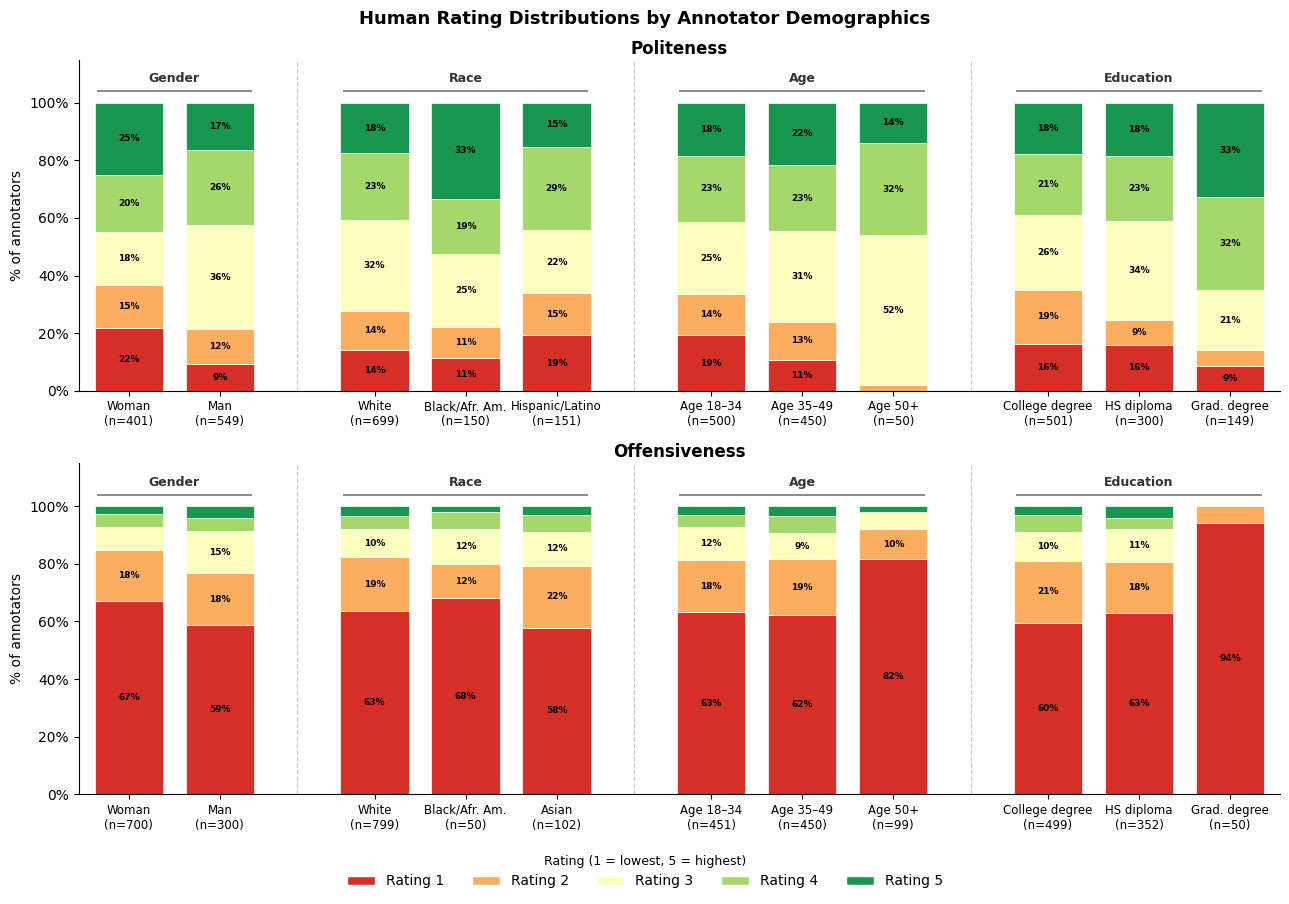

In [3]:
colors = plt.cm.RdYlGn(np.linspace(0.1, 0.9, 5))  # 1=red, 3=yellow, 5=green

fig, axes = plt.subplots(2, 1, figsize=(13, 9))

datasets = [
    (data_pol, 'politeness',    'Politeness',    axes[0]),
    (data_off, 'offensiveness', 'Offensiveness', axes[1]),
]

for data, rating_col, title, ax in datasets:

    # ── build per-bar data ────────────────────────────────────────────────
    all_info  = []   # (x_pos, tick_label, n, dist)
    dim_spans = []   # (x_start, x_end, dim_name)
    x = 0.0

    for dim_name, col, groups in dimensions:
        x_start = x
        added = 0
        for g in groups:
            subset = data[data[col] == g]
            if len(subset) == 0:
                continue
            n = len(subset)
            counts = subset[rating_col].value_counts(normalize=True) * 100
            dist = [counts.get(r, 0) for r in ratings]
            all_info.append((x, f'{g}\n(n={n})', n, dist))
            x += 1.0
            added += 1
        if added:
            dim_spans.append((x_start, x - 1.0, dim_name))
        x += 0.7   # gap between demographic dimensions

    xs    = np.array([info[0] for info in all_info])
    xlabs = [info[1] for info in all_info]
    dists = [info[3] for info in all_info]

    # ── stacked bars ─────────────────────────────────────────────────────
    bottoms = np.zeros(len(xs))
    for ri, (r, color) in enumerate(zip(ratings, colors)):
        vals = np.array([d[ri] for d in dists])
        ax.bar(xs, vals, bottom=bottoms, color=color, width=0.75,
               label=f'Rating {r}', edgecolor='white', linewidth=0.5)
        # annotate segments ≥ 8 pp wide
        for xi, (v, b) in enumerate(zip(vals, bottoms)):
            if v >= 8:
                ax.text(xs[xi], b + v / 2, f'{v:.0f}%',
                        ha='center', va='center', fontsize=6.5,
                        color='black', fontweight='bold')
        bottoms += vals

    # ── dimension labels + bracket lines above bars ───────────────────────
    ax.set_ylim(0, 115)
    for x_s, x_e, dname in dim_spans:
        mid = (x_s + x_e) / 2
        # bracket
        ax.plot([x_s - 0.35, x_e + 0.35], [104, 104],
                color='#777777', lw=1.2, solid_capstyle='butt', clip_on=False)
        ax.text(mid, 106, dname, ha='center', va='bottom',
                fontsize=9, fontweight='bold', color='#333333')

    # ── vertical separators between dimensions ───────────────────────────
    for i in range(len(dim_spans) - 1):
        boundary = (dim_spans[i][1] + dim_spans[i + 1][0]) / 2
        ax.axvline(boundary, color='#bbbbbb', linestyle='--', lw=0.9, alpha=0.8)

    # ── axes formatting ──────────────────────────────────────────────────
    ax.set_xticks(xs)
    ax.set_xticklabels(xlabs, fontsize=8.5)
    ax.set_ylabel('% of annotators', fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=4)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))
    ax.set_xlim(xs[0] - 0.55, xs[-1] + 0.55)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── shared legend ────────────────────────────────────────────────────────
handles = [mpatches.Patch(facecolor=colors[i], label=f'Rating {r}', edgecolor='white')
           for i, r in enumerate(ratings)]
fig.legend(handles=handles, loc='lower center', ncol=5,
           fontsize=10, title='Rating (1 = lowest, 5 = highest)', title_fontsize=9,
           bbox_to_anchor=(0.5, -0.01), frameon=False)

fig.suptitle('Human Rating Distributions by Annotator Demographics', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('figures/rating_distributions.pdf', dpi=150, bbox_inches='tight')
plt.show()